<a href="https://colab.research.google.com/github/cynthiazhang98/COMSW4995-cynthiazhang98-A2/blob/main/COMSW4995_A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup and Imports

In [1]:
from google.colab import files
uploaded = files.upload()

Saving bank-full.csv to bank-full.csv


In [2]:
# Core
import pandas as pd
import numpy as np
import time

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Models
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import xgboost as xgb

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

# Reproducibility
import random
random.seed(42)
np.random.seed(42)

##Data Loading and Exploration  


In [3]:
df = pd.read_csv('bank-full.csv', sep=';')

print(df.shape)
print(df.head())
print(df.dtypes)

(45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
age           int64
job          object
marital      object
education    object
default      object

In [4]:
numeric_cols = df.select_dtypes(include=['int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

categorical_cols = [col for col in categorical_cols if col != 'y']

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)

Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total missing: 0


In [6]:
print("'Unknown' value counts per categorical column:\n")
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"{col}: {unknown_count} unknowns ({pct:.1f}%)")

'Unknown' value counts per categorical column:

job: 288 unknowns (0.6%)
education: 1857 unknowns (4.1%)
contact: 13020 unknowns (28.8%)
poutcome: 36959 unknowns (81.7%)


In [7]:
print(df[numeric_cols].describe())

                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.

Target variable distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

As percentages:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


/tmp/ipykernel_30972/2921092822.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=df, palette='Blues')


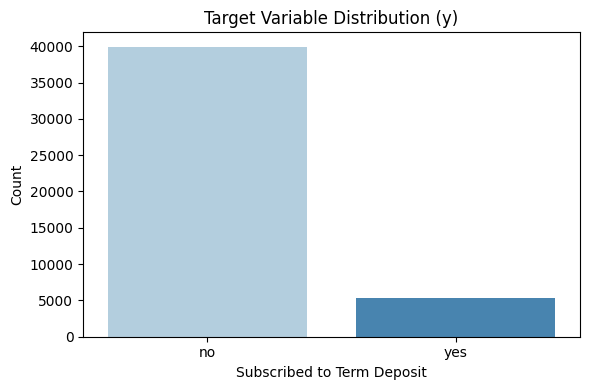

In [8]:
print("Target variable distribution:")
print(df['y'].value_counts())
print("\nAs percentages:")
print(df['y'].value_counts(normalize=True).round(3) * 100)

# Visualize
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df, palette='Blues')
plt.title('Target Variable Distribution (y)')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

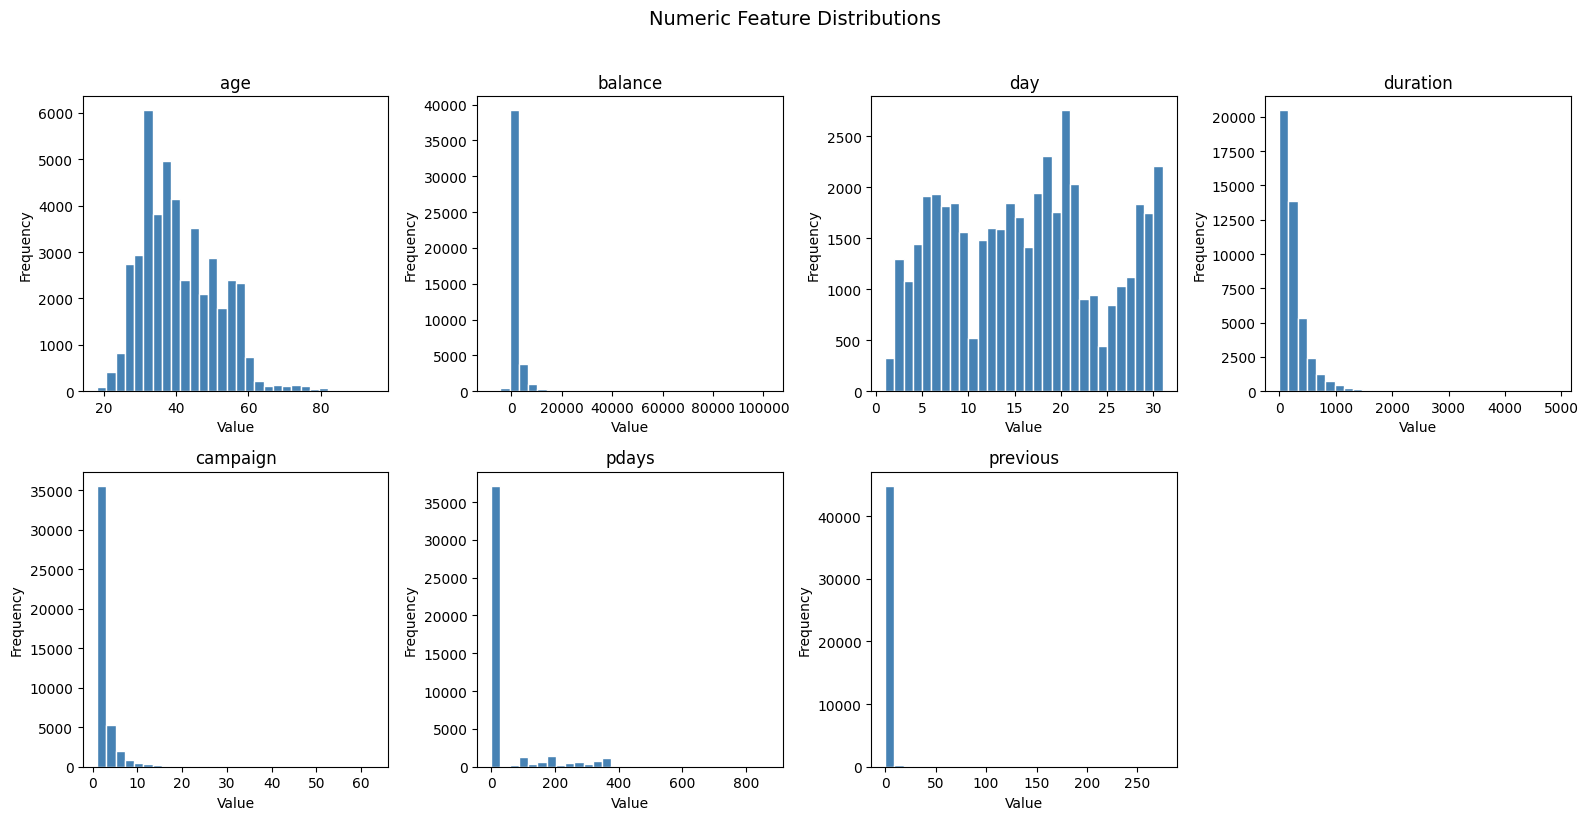

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

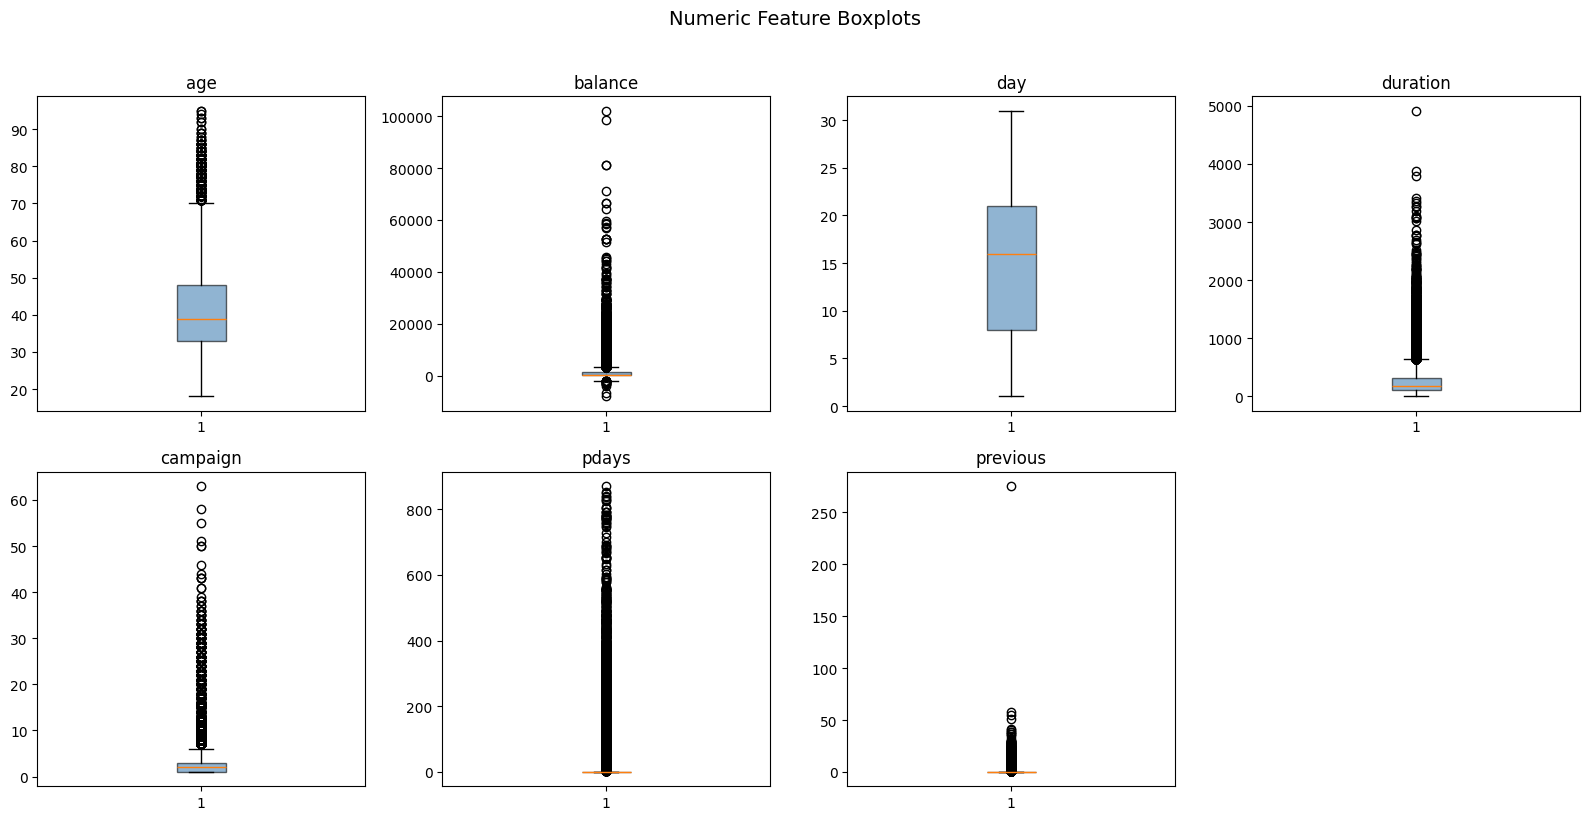

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Boxplots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

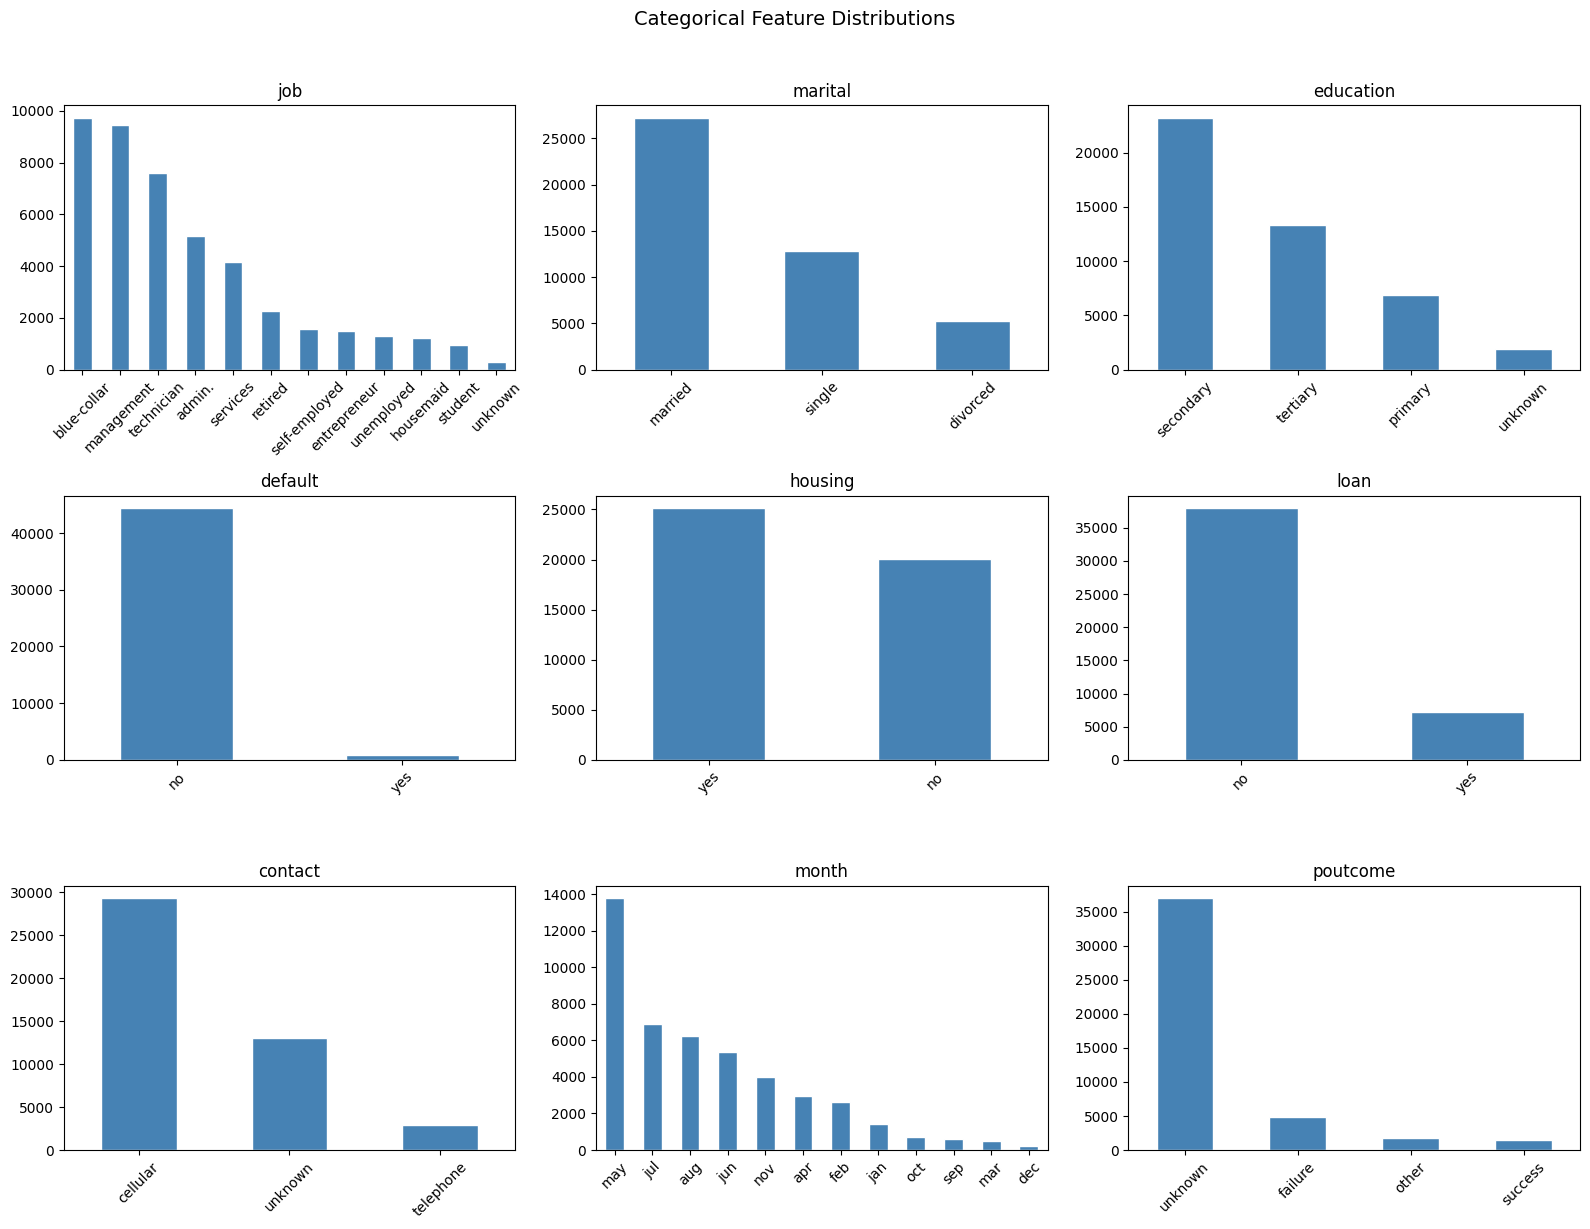

In [11]:
#categorical value counts:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i],
                                 color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

"pdays" analyzation

In [12]:
print("pdays value breakdown:")
print(f"Value of -1 (never contacted): {(df['pdays'] == -1).sum()}")
print(f"Other values (previously contacted): {(df['pdays'] != -1).sum()}")
print(f"\npdays statistics excluding -1:")
print(df[df['pdays'] != -1]['pdays'].describe())

pdays value breakdown:
Value of -1 (never contacted): 36954
Other values (previously contacted): 8257

pdays statistics excluding -1:
count    8257.000000
mean      224.577692
std       115.344035
min         1.000000
25%       133.000000
50%       194.000000
75%       327.000000
max       871.000000
Name: pdays, dtype: float64


In [13]:
print("Skewness of numeric features:")
print(df[numeric_cols].skew().round(2).sort_values(ascending=False))

Skewness of numeric features:
previous    41.85
balance      8.36
campaign     4.90
duration     3.14
pdays        2.62
age          0.68
day          0.09
dtype: float64


"default" analyzation

In [14]:
default_crosstab = pd.crosstab(df['default'], df['y'], normalize='index') * 100
print("Subscription rate by default status (%):")
print(default_crosstab.round(2))

print("\nRaw counts:")
print(pd.crosstab(df['default'], df['y']))

print("\nDefault distribution:")
print(df['default'].value_counts())
print(df['default'].value_counts(normalize=True).round(3) * 100)

Subscription rate by default status (%):
y           no    yes
default              
no       88.20  11.80
yes      93.62   6.38

Raw counts:
y           no   yes
default             
no       39159  5237
yes        763    52

Default distribution:
default
no     44396
yes      815
Name: count, dtype: int64
default
no     98.2
yes     1.8
Name: proportion, dtype: float64


"previous" analyzation

In [15]:
print("previous column statistics:")
print(df['previous'].describe())

print("\nValue counts for previous > 20:")
print(df[df['previous'] > 20]['previous'].value_counts().sort_index())

print("\nRows where previous > 50:")
extreme_previous = df[df['previous'] > 50]
print(extreme_previous)
print(f"\nTotal extreme rows: {len(extreme_previous)}")

print("\nDid extreme previous contact customers subscribe?")
print(extreme_previous['y'].value_counts())

previous column statistics:
count    45211.000000
mean         0.580323
std          2.303441
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64

Value counts for previous > 20:
previous
21     4
22     6
23     8
24     5
25     4
26     2
27     5
28     2
29     4
30     3
32     1
35     1
37     2
38     2
40     1
41     1
51     1
55     1
58     1
275    1
Name: count, dtype: int64

Rows where previous > 50:
       age          job  marital  education default  balance housing loan  \
28886   31   management   single   tertiary      no      358     yes   no   
29182   40   management  married   tertiary      no      543     yes   no   
38326   46  blue-collar  married    primary      no     1085     yes  yes   
44089   37   technician  married  secondary      no      432     yes   no   

        contact  day month  duration  campaign  pdays  previous poutcome    y  
28886  cellular   30   j

"duration" and "balance" analyzation

In [16]:
print("Duration statistics:")
print(df['duration'].describe())
print(f"\nCalls over 1 hour (3600s): {(df['duration'] > 3600).sum()}")
print(f"Calls over 1.5 hours (5400s): {(df['duration'] > 5400).sum()}")

print("\nLongest calls:")
print(df.nlargest(5, 'duration')[['age', 'job', 'duration', 'campaign', 'y']])

print("\nBalance statistics:")
print(df['balance'].describe())
print(f"\nBalances over 50000: {(df['balance'] > 50000).sum()}")
print(f"Negative balances: {(df['balance'] < 0).sum()}")

print("\nHighest balances:")
print(df.nlargest(5, 'balance')[['age', 'job', 'balance', 'y']])

print("\nNegative balance rows:")
print(df[df['balance'] < 0][['age', 'job', 'balance', 'y']].head())

Duration statistics:
count    45211.000000
mean       258.163080
std        257.527812
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

Calls over 1 hour (3600s): 3
Calls over 1.5 hours (5400s): 0

Longest calls:
       age          job  duration  campaign    y
24148   59   technician      4918         1   no
9947    59   management      3881         3  yes
44602   45     services      3785         1   no
19639   37  blue-collar      3422         2   no
2386    45  blue-collar      3366         3   no

Balance statistics:
count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

Balances over 50000: 18
Negative balances: 3766

Highest balances:
       age         job  balance    y
39989   51  management   102127   no
26227   59  management 

zero-duration calls

In [17]:
print(f"Calls with 0 duration: {(df['duration'] == 0).sum()}")

print("\nZero duration rows sample:")
print(df[df['duration'] == 0][['age', 'job', 'duration', 'campaign', 'y']].head(10))

print("\nZero duration subscription rate:")
print(df[df['duration'] == 0]['y'].value_counts())
print(df[df['duration'] == 0]['y'].value_counts(normalize=True).round(3) * 100)

Calls with 0 duration: 3

Zero duration rows sample:
       age           job  duration  campaign   y
6424    53    management         0         4  no
22937   35    technician         0        15  no
36425   31  entrepreneur         0         2  no

Zero duration subscription rate:
y
no    3
Name: count, dtype: int64
y
no    100.0
Name: proportion, dtype: float64


duplicate checks

In [18]:
print(f"Total duplicate rows: {df.duplicated().sum()}")

print("\nRows with age=84 and balance=81204:")
print(df[(df['age'] == 84) & (df['balance'] == 81204)])

if df.duplicated().sum() > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

Total duplicate rows: 0

Rows with age=84 and balance=81204:
       age      job  marital  education default  balance housing loan  \
42558   84  retired  married  secondary      no    81204      no   no   
43393   84  retired  married  secondary      no    81204      no   no   

         contact  day month  duration  campaign  pdays  previous poutcome    y  
42558  telephone   28   dec       679         1    313         2    other  yes  
43393  telephone    1   apr       390         1     94         3  success  yes  


##Data Preparation

Drop extreme outlier in previous

In [19]:
df = df[df['previous'] != 275].copy()
print(f"Rows after dropping: {len(df)}")

Rows after dropping: 45210


In [20]:
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3) * 100)

Feature matrix shape: (45210, 16)
Target distribution:
y
0    39921
1     5289
Name: count, dtype: int64
y
0    88.3
1    11.7
Name: proportion, dtype: float64


Data Splitting 70-15-15

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y  # important for the imbalanced data
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation size: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print("\nClass balance check:")
print(f"Train yes rate: {y_train.mean()*100:.1f}%")
print(f"Val yes rate: {y_val.mean()*100:.1f}%")
print(f"Test yes rate: {y_test.mean()*100:.1f}%")

Train size: 31647 (70.0%)
Validation size: 6781 (15.0%)
Test size: 6782 (15.0%)

Class balance check:
Train yes rate: 11.7%
Val yes rate: 11.7%
Test yes rate: 11.7%


###Feature Engineering
new feature 'was_previously_contacted'

In [22]:
for dataset in [X_train, X_val, X_test]:
    dataset['was_previously_contacted'] = (dataset['pdays'] != -1).astype(int)

print("was_previously_contacted distribution in train:")
print(X_train['was_previously_contacted'].value_counts())
print(X_train['was_previously_contacted'].value_counts(normalize=True).round(3) * 100)

print("\nVerify pdays still exists:")
print(X_train[['pdays', 'was_previously_contacted']].head(10))

was_previously_contacted distribution in train:
was_previously_contacted
0    25896
1     5751
Name: count, dtype: int64
was_previously_contacted
0    81.8
1    18.2
Name: proportion, dtype: float64

Verify pdays still exists:
       pdays  was_previously_contacted
21491     -1                         0
31217     -1                         0
3991      -1                         0
8068      -1                         0
27483     -1                         0
10131     -1                         0
26348     -1                         0
10624     -1                         0
31324     -1                         0
8433      -1                         0


one hot encode for categorical

In [23]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

X_train = pd.get_dummies(X_train, columns=cat_cols)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"\nShape after encoding:")
print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")

print("\nAll columns after encoding:")
print(X_train.columns.tolist())

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Shape after encoding:
Train: (31647, 52)
Val: (6781, 52)
Test: (6782, 52)

All columns after encoding:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'was_previously_contacted', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married', 'marital_single', 'education_primary', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_no', 'default_yes', 'housing_no', 'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular', 'contact_telephone', 'contact_unknown', 'month_apr', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_failure', 'pout

Scale for MLP

In [24]:
numeric_cols_to_scale = ['age', 'balance', 'day', 'duration',
                          'campaign', 'pdays', 'previous']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols_to_scale] = scaler.fit_transform(
    X_train[numeric_cols_to_scale]
)
X_val_scaled[numeric_cols_to_scale] = scaler.transform(
    X_val[numeric_cols_to_scale]
)
X_test_scaled[numeric_cols_to_scale] = scaler.transform(
    X_test[numeric_cols_to_scale]
)

print("After scaling - numeric columns in train:")
print("Means (should be ~0):")
print(X_train_scaled[numeric_cols_to_scale].mean().round(3))
print("\nStd (should be ~1):")
print(X_train_scaled[numeric_cols_to_scale].std().round(3))

print("\nVerify XGBoost data unscaled - balance mean:")
print(X_train['balance'].mean().round(2))

After scaling - numeric columns in train:
Means (should be ~0):
age         0.0
balance    -0.0
day        -0.0
duration   -0.0
campaign   -0.0
pdays       0.0
previous    0.0
dtype: float64

Std (should be ~1):
age         1.0
balance     1.0
day         1.0
duration    1.0
campaign    1.0
pdays       1.0
previous    1.0
dtype: float64

Verify XGBoost data unscaled - balance mean:
1376.32


Final Verification

In [25]:
print("\nFor XGBoost (unscaled):")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")

print("\nFor MLP (scaled):")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled: {X_val_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

print("\nTarget sizes:")
print(f"y_train: {len(y_train)}")
print(f"y_val: {len(y_val)}")
print(f"y_test: {len(y_test)}")

print("\nClass balance in each split:")
print(f"Train yes rate: {y_train.mean()*100:.1f}%")
print(f"Val yes rate: {y_val.mean()*100:.1f}%")
print(f"Test yes rate: {y_test.mean()*100:.1f}%")



For XGBoost (unscaled):
X_train: (31647, 52)
X_val: (6781, 52)
X_test: (6782, 52)

For MLP (scaled):
X_train_scaled: (31647, 52)
X_val_scaled: (6781, 52)
X_test_scaled: (6782, 52)

Target sizes:
y_train: 31647
y_val: 6781
y_test: 6782

Class balance in each split:
Train yes rate: 11.7%
Val yes rate: 11.7%
Test yes rate: 11.7%


##GBDT Implementation

In [26]:
!pip install xgboost --quiet


Setup with early stopping

In [27]:
xgb_model = XGBClassifier(
    learning_rate=0.1,
    n_estimators=500,
    max_depth=4,
    subsample=0.8,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    eval_metric='aucpr',
    early_stopping_rounds=20
)

start_time = time.time()

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

xgb_train_time = time.time() - start_time
print(f"\nTraining time: {xgb_train_time:.2f} seconds")
print(f"Best iteration: {xgb_model.best_iteration}")

[0]	validation_0-aucpr:0.50982	validation_1-aucpr:0.37024
[50]	validation_0-aucpr:0.65515	validation_1-aucpr:0.40979
[100]	validation_0-aucpr:0.69653	validation_1-aucpr:0.42424
[150]	validation_0-aucpr:0.72674	validation_1-aucpr:0.42864
[158]	validation_0-aucpr:0.73122	validation_1-aucpr:0.42846

Training time: 7.76 seconds
Best iteration: 138


Training vs Validation Loss Curve

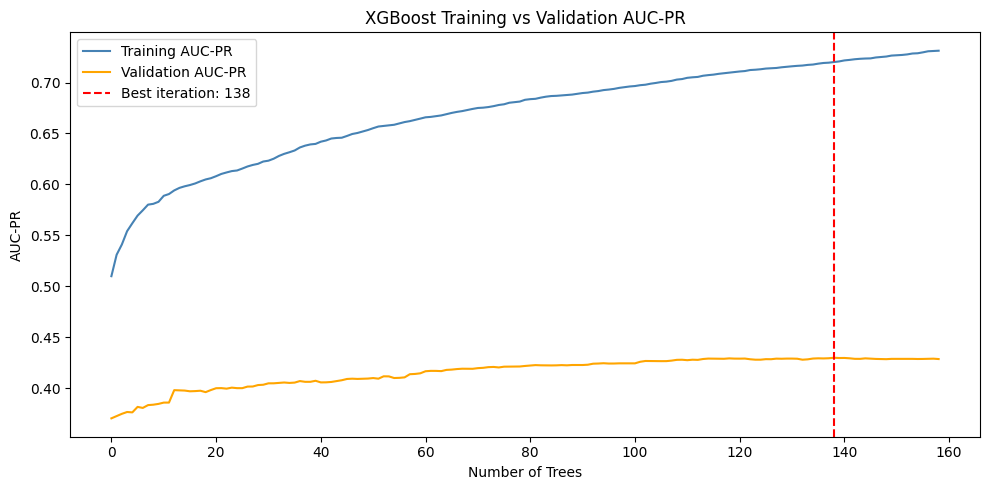

In [28]:
# Extract results from training
results = xgb_model.evals_result()
train_scores = results['validation_0']['aucpr']
val_scores = results['validation_1']['aucpr']

plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Training AUC-PR', color='steelblue')
plt.plot(val_scores, label='Validation AUC-PR', color='orange')
plt.axvline(x=xgb_model.best_iteration, color='red',
            linestyle='--', label=f'Best iteration: {xgb_model.best_iteration}')
plt.xlabel('Number of Trees')
plt.ylabel('AUC-PR')
plt.title('XGBoost Training vs Validation AUC-PR')
plt.legend()
plt.tight_layout()
plt.show()

Parameter exploration

In [29]:
# Explore max_depth effect
depths = [3, 4, 6, 8]
depth_results = {}

for depth in depths:
    model = XGBClassifier(
        learning_rate=0.1,
        n_estimators=500,
        max_depth=depth,
        subsample=0.8,
        #xgboost defaults alpha=0 lambda=1
        random_state=42,
        eval_metric='aucpr',
        early_stopping_rounds=20
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    val_aucpr = max(model.evals_result()['validation_1']['aucpr'])
    depth_results[depth] = val_aucpr
    print(f"max_depth={depth}: best val AUC-PR={val_aucpr:.4f}, "
          f"best iteration={model.best_iteration}")

# Explore subsample effect
subsamples = [0.5, 0.8, 1.0]
subsample_results = {}

for sub in subsamples:
    model = XGBClassifier(
        learning_rate=0.1,
        n_estimators=500,
        max_depth=4,
        subsample=sub,
        #xgboost defaults alpha=0 lambda=1
        random_state=42,
        eval_metric='aucpr',
        early_stopping_rounds=20
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    val_aucpr = max(model.evals_result()['validation_1']['aucpr'])
    subsample_results[sub] = val_aucpr
    print(f"subsample={sub}: best val AUC-PR={val_aucpr:.4f}, "
          f"best iteration={model.best_iteration}")

# Explore regularization effect
reg_params = [
    {'reg_alpha': 0, 'reg_lambda': 1},    # default
    {'reg_alpha': 0.1, 'reg_lambda': 1},  # light L1
    {'reg_alpha': 0, 'reg_lambda': 5},    # stronger L2
    {'reg_alpha': 0.1, 'reg_lambda': 5},  # both
]
reg_results = {}

for params in reg_params:
    label = f"alpha={params['reg_alpha']}, lambda={params['reg_lambda']}"
    model = XGBClassifier(
        learning_rate=0.1,
        n_estimators=500,
        max_depth=4,
        subsample=0.8,
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=42,
        eval_metric='aucpr',
        early_stopping_rounds=20
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    val_aucpr = max(model.evals_result()['validation_1']['aucpr'])
    reg_results[label] = val_aucpr
    print(f"{label}: best val AUC-PR={val_aucpr:.4f}")

max_depth=3: best val AUC-PR=0.4091, best iteration=56
max_depth=4: best val AUC-PR=0.4297, best iteration=138
max_depth=6: best val AUC-PR=0.4211, best iteration=66
max_depth=8: best val AUC-PR=0.4250, best iteration=76
subsample=0.5: best val AUC-PR=0.4214, best iteration=89
subsample=0.8: best val AUC-PR=0.4297, best iteration=138
subsample=1.0: best val AUC-PR=0.4179, best iteration=216
alpha=0, lambda=1: best val AUC-PR=0.4297
alpha=0.1, lambda=1: best val AUC-PR=0.4242
alpha=0, lambda=5: best val AUC-PR=0.4238
alpha=0.1, lambda=5: best val AUC-PR=0.4209


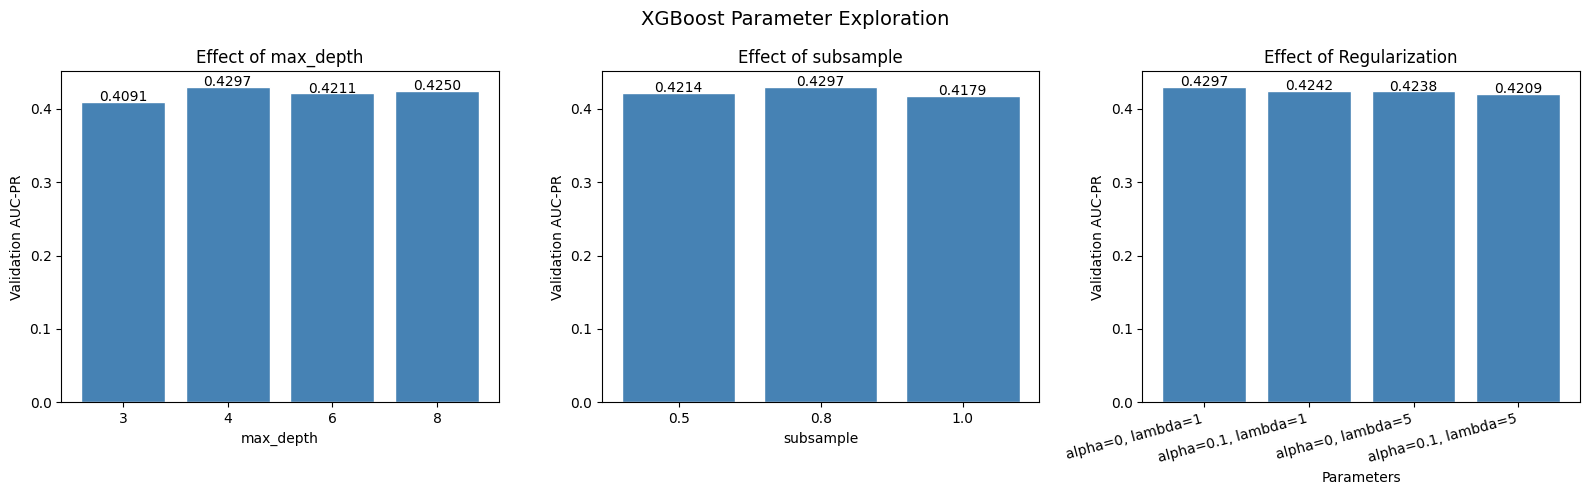

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Max depth plot
axes[0].bar([str(d) for d in depths],
            list(depth_results.values()),
            color='steelblue', edgecolor='white')
axes[0].set_title('Effect of max_depth')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Validation AUC-PR')
for i, v in enumerate(depth_results.values()):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center')

# Subsample plot
axes[1].bar([str(s) for s in subsamples],
            list(subsample_results.values()),
            color='steelblue', edgecolor='white')
axes[1].set_title('Effect of subsample')
axes[1].set_xlabel('subsample')
axes[1].set_ylabel('Validation AUC-PR')
for i, v in enumerate(subsample_results.values()):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center')

# Regularization plot
axes[2].bar(range(len(reg_results)),
            list(reg_results.values()),
            color='steelblue', edgecolor='white')
axes[2].set_xticks(range(len(reg_results)))
axes[2].set_xticklabels(list(reg_results.keys()), rotation=15, ha='right')
axes[2].set_title('Effect of Regularization')
axes[2].set_xlabel('Parameters')
axes[2].set_ylabel('Validation AUC-PR')
for i, v in enumerate(reg_results.values()):
    axes[2].text(i, v + 0.001, f'{v:.4f}', ha='center')

plt.suptitle('XGBoost Parameter Exploration', fontsize=14)
plt.tight_layout()
plt.show()

Feature Importance

<Figure size 1000x800 with 0 Axes>

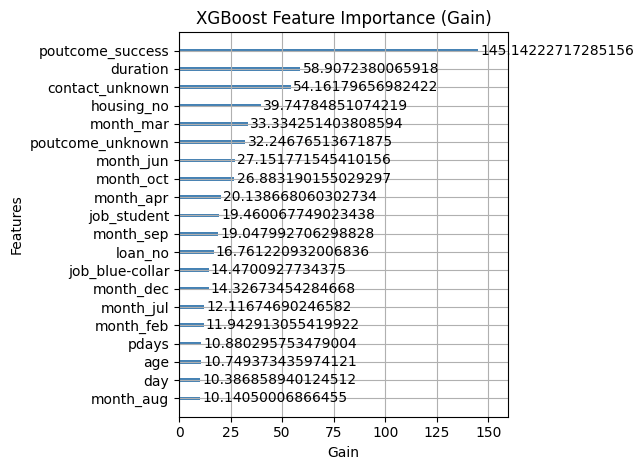

Top 10 most important features:
             feature  importance
50  poutcome_success    0.192498
3           duration    0.078127
35   contact_unknown    0.071833
29        housing_no    0.052716
43         month_mar    0.044210
51  poutcome_unknown    0.042768
42         month_jun    0.036011
46         month_oct    0.035654
36         month_apr    0.026709
16       job_student    0.025809


In [31]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=20,
                    importance_type='gain',
                    title='XGBoost Feature Importance (Gain)',
                    xlabel='Gain',
                    color='steelblue')
plt.tight_layout()
plt.show()

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 most important features:")
print(feature_importance_df.head(10))

Learning Rate Comparison

In [32]:
learning_rates = [0.01, 0.1, 0.3]
lr_results = {}

for lr in learning_rates:
    model = XGBClassifier(
        learning_rate=lr,
        n_estimators=500,
        max_depth=4,
        subsample=0.8,
        reg_alpha=0,
        reg_lambda=1,
        random_state=42,
        eval_metric='aucpr',
        early_stopping_rounds=20
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )

    lr_results[lr] = {
        'train': model.evals_result()['validation_0']['aucpr'],
        'val': model.evals_result()['validation_1']['aucpr'],
        'best_iteration': model.best_iteration
    }

    print(f"LR={lr}: best iteration={model.best_iteration}, "
          f"best val AUC-PR={max(model.evals_result()['validation_1']['aucpr']):.4f}")

LR=0.01: best iteration=95, best val AUC-PR=0.3906
LR=0.1: best iteration=138, best val AUC-PR=0.4297
LR=0.3: best iteration=22, best val AUC-PR=0.4101


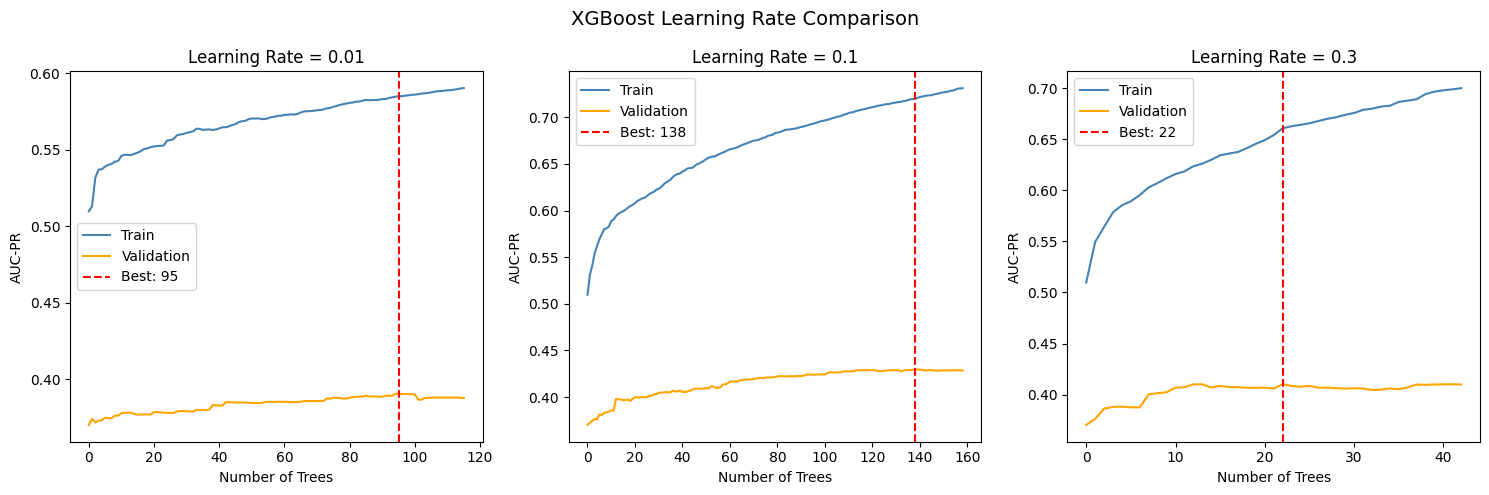

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, lr in enumerate(learning_rates):
    axes[i].plot(lr_results[lr]['train'],
                 label='Train', color='steelblue')
    axes[i].plot(lr_results[lr]['val'],
                 label='Validation', color='orange')
    axes[i].axvline(x=lr_results[lr]['best_iteration'],
                    color='red', linestyle='--',
                    label=f"Best: {lr_results[lr]['best_iteration']}")
    axes[i].set_title(f'Learning Rate = {lr}')
    axes[i].set_xlabel('Number of Trees')
    axes[i].set_ylabel('AUC-PR')
    axes[i].legend()

plt.suptitle('XGBoost Learning Rate Comparison', fontsize=14)
plt.tight_layout()
plt.show()

##MLP Implementation

Setup

In [34]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

start_time = time.time()
mlp_model.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - start_time
print(f"Training time: {mlp_train_time:.2f} seconds")
print(f"Iterations completed: {mlp_model.n_iter_}")

Training time: 17.10 seconds
Iterations completed: 40


Training loss curve

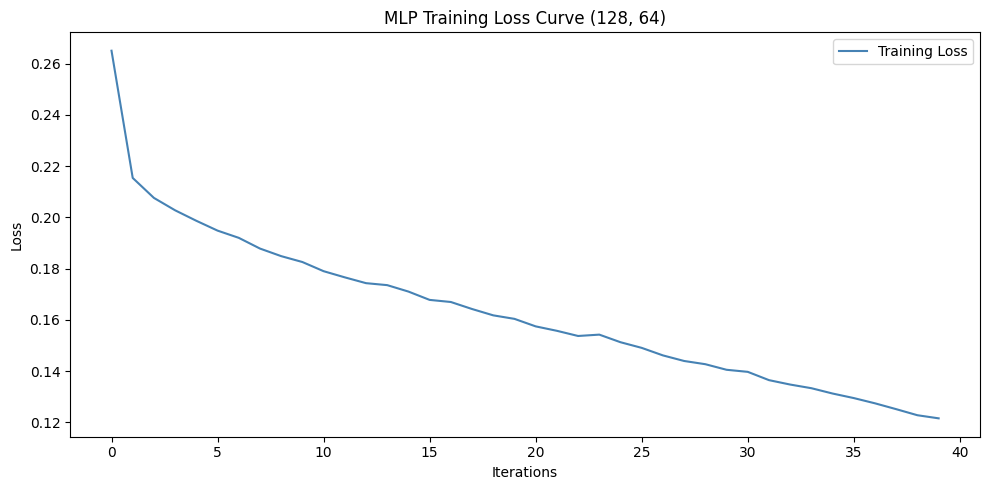

Final training loss: 0.1216


In [35]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_model.loss_curve_, color='steelblue', label='Training Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Training Loss Curve (128, 64)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final training loss: {mlp_model.loss_curve_[-1]:.4f}")

Network Depth/Width Comparison

In [36]:
architectures = {
    'Shallow (64,)': (64,),
    'Medium (128, 64)': (128, 64),
    'Deep (256, 128, 64)': (256, 128, 64)
}

arch_results = {}

for name, hidden_layers in architectures.items():
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation='relu',
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    # Evaluate on validation
    y_val_prob = model.predict_proba(X_val_scaled)[:, 1]
    y_val_pred = model.predict(X_val_scaled)
    val_aucpr = average_precision_score(y_val, y_val_prob)

    arch_results[name] = {
        'model': model,
        'loss_curve': model.loss_curve_,
        'val_aucpr': val_aucpr,
        'iterations': model.n_iter_
    }

    print(f"{name}: val AUC-PR={val_aucpr:.4f}, "
          f"iterations={model.n_iter_}")

Shallow (64,): val AUC-PR=0.3205, iterations=69
Medium (128, 64): val AUC-PR=0.2855, iterations=40
Deep (256, 128, 64): val AUC-PR=0.3335, iterations=27


Plot Architecture Comparison


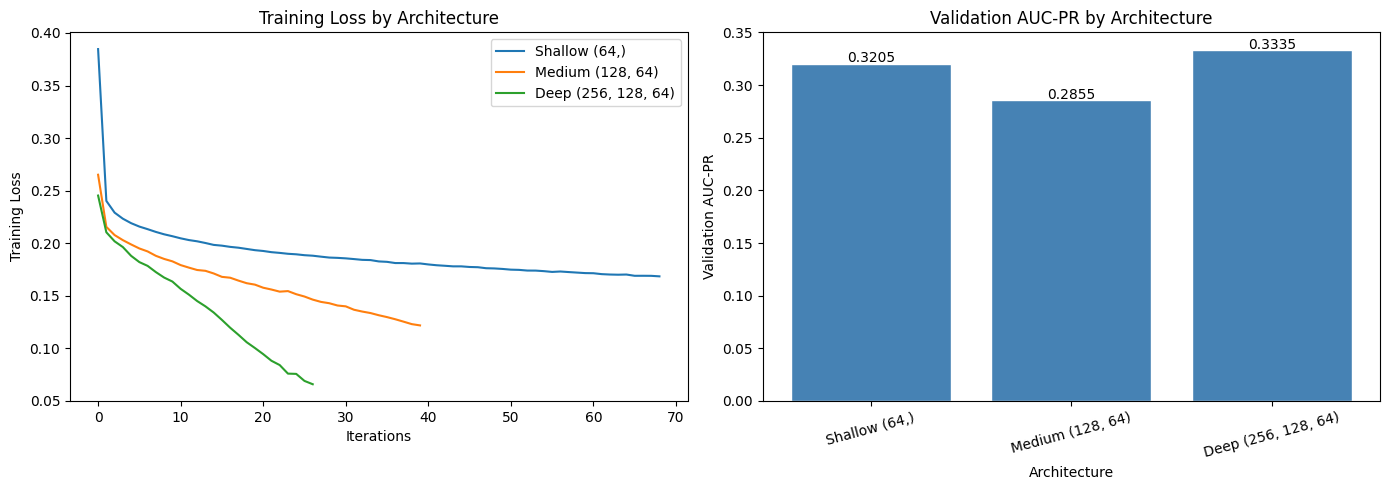

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: loss curves for each architecture
for name, results in arch_results.items():
    axes[0].plot(results['loss_curve'], label=name)
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss by Architecture')
axes[0].legend()

# Right plot: validation AUC-PR bar chart
names = list(arch_results.keys())
val_scores = [arch_results[name]['val_aucpr'] for name in names]
axes[1].bar(names, val_scores, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Architecture')
axes[1].set_ylabel('Validation AUC-PR')
axes[1].set_title('Validation AUC-PR by Architecture')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(val_scores):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.show()

Activation Function Comparison

Activation=relu: val AUC-PR=0.3335, iterations=27
Activation=tanh: val AUC-PR=0.3369, iterations=35


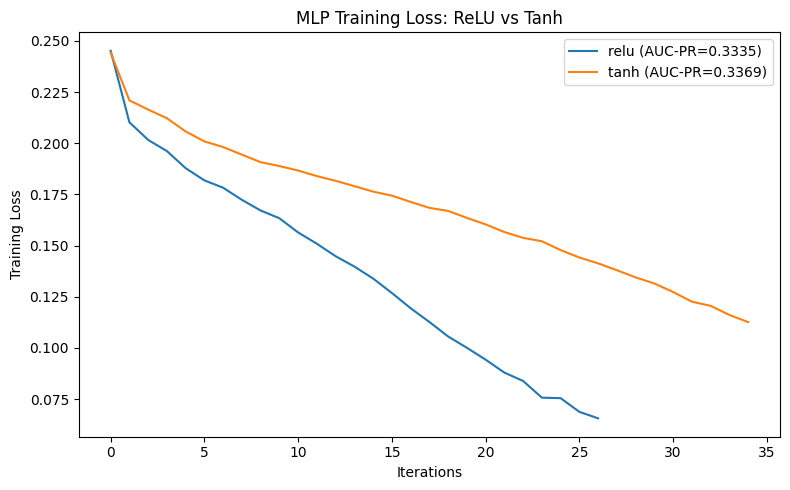

In [38]:
activations = ['relu', 'tanh']
activation_results = {}

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64), #changed cause its better
        activation=act,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_val_prob = model.predict_proba(X_val_scaled)[:, 1]
    val_aucpr = average_precision_score(y_val, y_val_prob)

    activation_results[act] = {
        'loss_curve': model.loss_curve_,
        'val_aucpr': val_aucpr,
        'iterations': model.n_iter_
    }

    print(f"Activation={act}: val AUC-PR={val_aucpr:.4f}, "
          f"iterations={model.n_iter_}")

# Plot comparison
plt.figure(figsize=(8, 5))
for act, results in activation_results.items():
    plt.plot(results['loss_curve'], label=f'{act} (AUC-PR={results["val_aucpr"]:.4f})')
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.title('MLP Training Loss: ReLU vs Tanh')
plt.legend()
plt.tight_layout()
plt.show()

Learning Rate Comparison

LR=0.001: val AUC-PR=0.3369, iterations=35
LR=0.01: val AUC-PR=0.2469, iterations=58
LR=0.1: val AUC-PR=0.3847, iterations=23


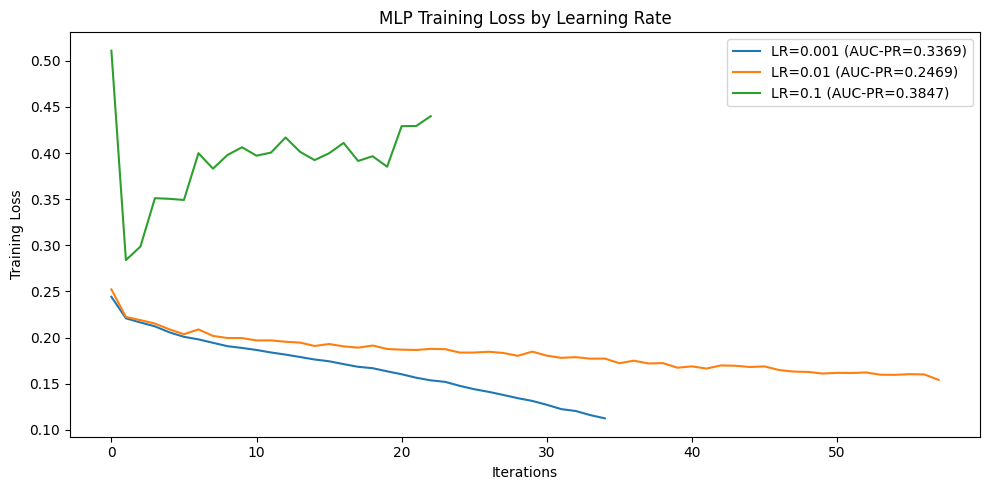

In [39]:
learning_rates_mlp = [0.001, 0.01, 0.1]
lr_mlp_results = {}

for lr in learning_rates_mlp:
    model = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='tanh',
        learning_rate_init=lr,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_val_prob = model.predict_proba(X_val_scaled)[:, 1]
    val_aucpr = average_precision_score(y_val, y_val_prob)

    lr_mlp_results[lr] = {
        'loss_curve': model.loss_curve_,
        'val_aucpr': val_aucpr,
        'iterations': model.n_iter_
    }

    print(f"LR={lr}: val AUC-PR={val_aucpr:.4f}, "
          f"iterations={model.n_iter_}")

# Plot
plt.figure(figsize=(10, 5))
for lr, results in lr_mlp_results.items():
    plt.plot(results['loss_curve'],
             label=f'LR={lr} (AUC-PR={results["val_aucpr"]:.4f})')
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.title('MLP Training Loss by Learning Rate')
plt.legend()
plt.tight_layout()
plt.show()

 Final Best MLP Evaluation

Best MLP Validation Performance:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      5988
           1       0.33      0.67      0.45       793

    accuracy                           0.80      6781
   macro avg       0.64      0.75      0.66      6781
weighted avg       0.88      0.80      0.83      6781

AUC-PR: 0.3847
Training time: 49.99 seconds


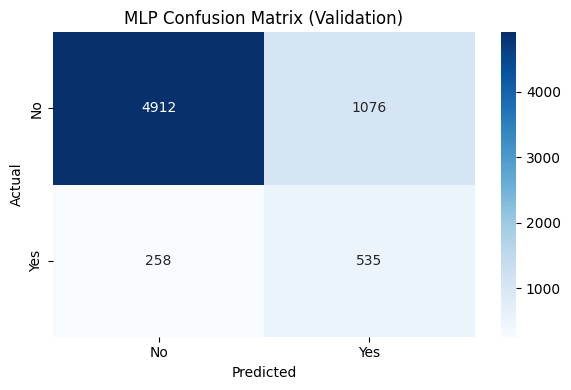

In [40]:
best_mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),  # deep won
    activation='tanh',                   # tanh won
    learning_rate_init=0.1,             # 0.1 won
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

start_time = time.time()
best_mlp.fit(X_train_scaled, y_train)
mlp_train_time = time.time() - start_time

y_val_pred = best_mlp.predict(X_val_scaled)
y_val_prob = best_mlp.predict_proba(X_val_scaled)[:, 1]

print("Best MLP Validation Performance:")
print(classification_report(y_val, y_val_pred))
print(f"AUC-PR: {average_precision_score(y_val, y_val_prob):.4f}")
print(f"Training time: {mlp_train_time:.2f} seconds")

# Confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_val, y_val_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('MLP Confusion Matrix (Validation)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

##GBDT vs MLP Comparison on Final Eval

In [41]:
# XGBoost predictions on test set
y_test_pred_xgb = xgb_model.predict(X_test)
y_test_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# MLP predictions on test set
y_test_pred_mlp = best_mlp.predict(X_test_scaled)
y_test_prob_mlp = best_mlp.predict_proba(X_test_scaled)[:, 1]

# XGBoost metrics
print("=" * 50)
print("XGBOOST TEST PERFORMANCE")
print("=" * 50)
print(classification_report(y_test, y_test_pred_xgb))
print(f"AUC-PR: {average_precision_score(y_test, y_test_prob_xgb):.4f}")

# MLP metrics
print("=" * 50)
print("MLP TEST PERFORMANCE")
print("=" * 50)
print(classification_report(y_test, y_test_pred_mlp))
print(f"AUC-PR: {average_precision_score(y_test, y_test_prob_mlp):.4f}")

XGBOOST TEST PERFORMANCE
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      5988
           1       0.60      0.19      0.28       794

    accuracy                           0.89      6782
   macro avg       0.75      0.58      0.61      6782
weighted avg       0.87      0.89      0.86      6782

AUC-PR: 0.4222
MLP TEST PERFORMANCE
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      5988
           1       0.32      0.63      0.43       794

    accuracy                           0.80      6782
   macro avg       0.63      0.73      0.65      6782
weighted avg       0.87      0.80      0.83      6782

AUC-PR: 0.3673


Summary Comparison Table

In [42]:
# Calculate all metrics for both models
metrics = {
    'Accuracy': [
        accuracy_score(y_test, y_test_pred_xgb),
        accuracy_score(y_test, y_test_pred_mlp)
    ],
    'Precision (yes)': [
        precision_score(y_test, y_test_pred_xgb),
        precision_score(y_test, y_test_pred_mlp)
    ],
    'Recall (yes)': [
        recall_score(y_test, y_test_pred_xgb),
        recall_score(y_test, y_test_pred_mlp)
    ],
    'F1-Score (yes)': [
        f1_score(y_test, y_test_pred_xgb),
        f1_score(y_test, y_test_pred_mlp)
    ],
    'AUC-PR': [
        average_precision_score(y_test, y_test_prob_xgb),
        average_precision_score(y_test, y_test_prob_mlp)
    ],
    'Training Time (s)': [
        round(xgb_train_time, 2),
        round(mlp_train_time, 2)
    ]
}

comparison_df = pd.DataFrame(metrics, index=['XGBoost', 'MLP'])
print(comparison_df.round(4))

         Accuracy  Precision (yes)  Recall (yes)  F1-Score (yes)  AUC-PR  \
XGBoost    0.8902           0.5992        0.1864          0.2843  0.4222   
MLP        0.8001           0.3208        0.6335          0.4259  0.3673   

         Training Time (s)  
XGBoost               7.76  
MLP                  49.99  


Side by Side Confusion Matrices

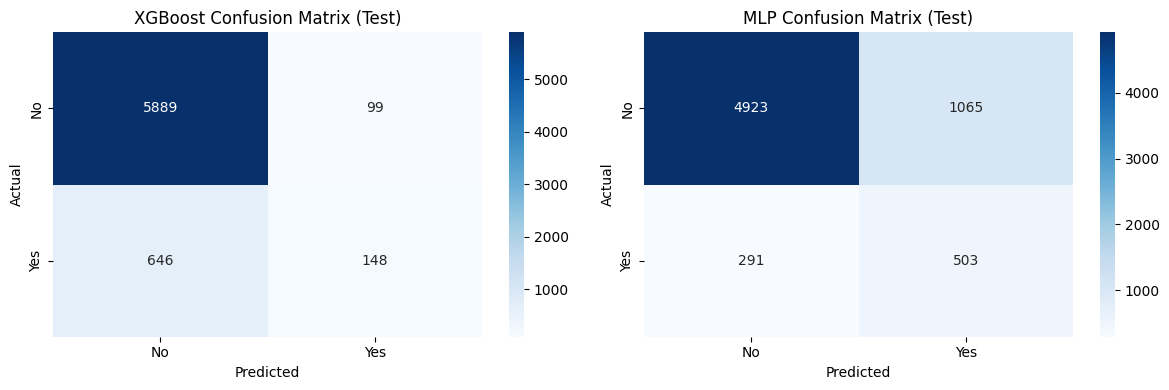

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# XGBoost confusion matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred_xgb),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'],
            ax=axes[0])
axes[0].set_title('XGBoost Confusion Matrix (Test)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# MLP confusion matrix
sns.heatmap(confusion_matrix(y_test, y_test_pred_mlp),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'],
            ax=axes[1])
axes[1].set_title('MLP Confusion Matrix (Test)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

Precision Recall Curves Side by Side

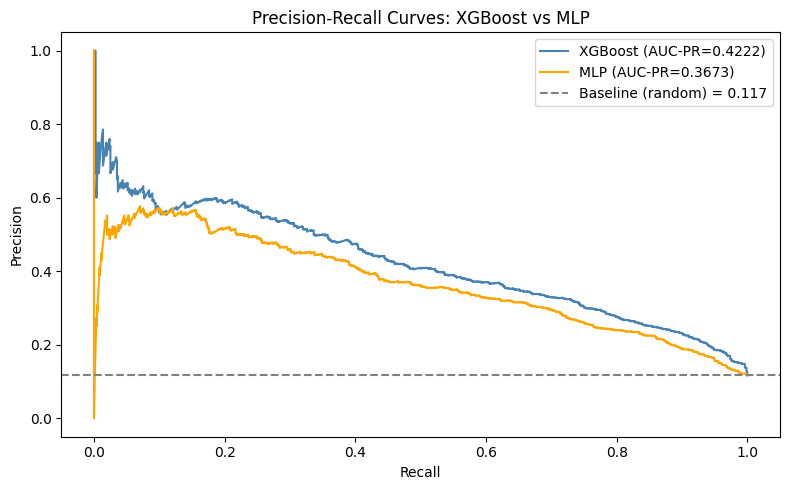

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))

# XGBoost PR curve
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_test_prob_xgb)
ax.plot(recall_xgb, precision_xgb,
        label=f'XGBoost (AUC-PR={average_precision_score(y_test, y_test_prob_xgb):.4f})',
        color='steelblue')

# MLP PR curve
precision_mlp, recall_mlp, _ = precision_recall_curve(y_test, y_test_prob_mlp)
ax.plot(recall_mlp, precision_mlp,
        label=f'MLP (AUC-PR={average_precision_score(y_test, y_test_prob_mlp):.4f})',
        color='orange')

# Baseline (random classifier)
ax.axhline(y=0.117, color='gray', linestyle='--',
           label='Baseline (random) = 0.117')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves: XGBoost vs MLP')
ax.legend()
plt.tight_layout()
plt.show()